# 18_ensemble_deeponet_fno.ipynb

Простой **ensemble DeepONet v2 + FNO v1** для задачи `sensor -> speed map`.

## Идея
Вместо нового сложного гибрида:
- загружаем уже обученный **DeepONet v2**,
- загружаем уже обученный **FNO v1**,
- подбираем вес ансамбля на `val`,
- оцениваем результат на `test`.

Финальное предсказание:

\[
\hat y = w \cdot y_{DeepONet} + (1 - w) \cdot y_{FNO}
\]

где `w` выбирается по `val`.

## 0. Важно
`M_hom` считается через `j-Wave`, поэтому JAX запускается на **CPU**.

Обе модели используются только в режиме **inference**.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "deeponet_ckpt": "/workspace/reference_points/deeponet_v2_main/deeponet_best.pt",
    "fno_ckpt": "/workspace/reference_points/fno_v1/fno_best.pt",
    "run_name": "ensemble_deeponet_fno_v1",
    "mask_half_width": 2,
    "use_residual": True,
    "search_weights": [round(x, 2) for x in np.linspace(0.0, 1.0, 21)],
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'deeponet_ckpt': '/workspace/reference_points/deeponet_v2_main/deeponet_best.pt',
 'fno_ckpt': '/workspace/reference_points/fno_v1/fno_best.pt',
 'run_name': 'ensemble_deeponet_fno_v1',
 'mask_half_width': 2,
 'use_residual': True,
 'search_weights': [np.float64(0.0),
  np.float64(0.05),
  np.float64(0.1),
  np.float64(0.15),
  np.float64(0.2),
  np.float64(0.25),
  np.float64(0.3),
  np.float64(0.35),
  np.float64(0.4),
  np.float64(0.45),
  np.float64(0.5),
  np.float64(0.55),
  np.float64(0.6),
  np.float64(0.65),
  np.float64(0.7),
  np.float64(0.75),
  np.float64(0.8),
  np.float64(0.85),
  np.float64(0.9),
  np.float64(0.95),
  np.float64(1.0)]}

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"
DEEPO_CKPT_PATH = Path(CFG["deeponet_ckpt"])
FNO_CKPT_PATH = Path(CFG["fno_ckpt"])

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR
assert DEEPO_CKPT_PATH.exists(), DEEPO_CKPT_PATH
assert FNO_CKPT_PATH.exists(), FNO_CKPT_PATH

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))
print("DeepONet ckpt:", DEEPO_CKPT_PATH)
print("FNO ckpt:", FNO_CKPT_PATH)

train: 6200
val: 1000
test: 800
DeepONet ckpt: /workspace/reference_points/deeponet_v2_main/deeponet_best.pt
FNO ckpt: /workspace/reference_points/fno_v1/fno_best.pt


In [5]:
sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

all_c_values = []
for p in train_files:
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}
print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 1. `M_hom` через j-Wave

In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [7]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_283492/1657452440.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 7.251914739608765 sec


## 2. Dataset with normalization to `[-1, 1]`

In [9]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTEnsembleDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = self.normalize_target(c).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )

In [10]:
ds_train = USCTEnsembleDataset(train_files, stats["c_min"], stats["c_max"], M_hom_complex=M_hom_complex, use_residual=CFG["use_residual"], mask_half_width=CFG["mask_half_width"])
ds_val = USCTEnsembleDataset(val_files, stats["c_min"], stats["c_max"], M_hom_complex=M_hom_complex, use_residual=CFG["use_residual"], mask_half_width=CFG["mask_half_width"])
ds_test = USCTEnsembleDataset(test_files, stats["c_min"], stats["c_max"], M_hom_complex=M_hom_complex, use_residual=CFG["use_residual"], mask_half_width=CFG["mask_half_width"])

x0, c0, meta0 = ds_train[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print(meta0)

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32 -0.7392016053199768 0.5010437965393066
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.529296875}


## 3. Model definitions

In [11]:
class BranchEncoderV2(nn.Module):
    def __init__(self, out_dim=192, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, 32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 64),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
            nn.Conv2d(128, 192, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 192),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(192 * 2 * 32, 384),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(384, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class TrunkNetV2(nn.Module):
    def __init__(self, width=192, hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.num_fourier_features = int(num_fourier_features)

        if self.num_fourier_features > 0:
            freq = 2.0 ** torch.arange(self.num_fourier_features, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.num_fourier_features
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode_coords(self, coords):
        if self.num_fourier_features == 0:
            return coords

        y = coords[:, 0:1]
        x = coords[:, 1:2]
        y_proj = y * self.freq[None, :]
        x_proj = x * self.freq[None, :]

        feats = [
            coords,
            torch.sin(y_proj),
            torch.cos(y_proj),
            torch.sin(x_proj),
            torch.cos(x_proj),
        ]
        return torch.cat(feats, dim=1)

    def forward(self, coords):
        return self.net(self.encode_coords(coords))

class DeepONet2DV2(nn.Module):
    def __init__(self, branch_width=192, trunk_width=192, trunk_hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.width = int(branch_width)
        self.branch = BranchEncoderV2(out_dim=branch_width, dropout=dropout)
        self.trunk = TrunkNetV2(
            width=trunk_width,
            hidden=trunk_hidden,
            num_fourier_features=num_fourier_features,
            dropout=dropout,
        )
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x, coords):
        b = self.branch(x)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        out = out.view(x.shape[0], 1, H, W)
        return out

In [12]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        x = x.float()
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )

        out_ft[:, :, : self.modes1, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, : self.modes1, : self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1 :, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1 :, : self.modes2], self.weights2
        )

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x

class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)

    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))

class FNO2dBaseline(nn.Module):
    def __init__(self, width=48, depth=4, modes1=24, modes2=24, padding=8):
        super().__init__()
        self.padding = padding
        self.input_proj = nn.Conv2d(4, width, kernel_size=1)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.head = nn.Sequential(
            nn.Conv2d(width, width, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(width, 1, kernel_size=1),
        )

    def get_grid(self, batch_size, device):
        yy = torch.linspace(-1.0, 1.0, H, device=device)
        xx = torch.linspace(-1.0, 1.0, W, device=device)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x):
        x = F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
        grid = self.get_grid(x.shape[0], x.device)
        x = torch.cat([x, grid], dim=1)
        x = self.input_proj(x)

        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])

        for block in self.blocks:
            x = block(x)

        if self.padding > 0:
            x = x[..., :H, :W]

        return self.head(x)

## 4. Load checkpoints

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

deeponet_ckpt = torch.load(DEEPO_CKPT_PATH, map_location=device)
fno_ckpt = torch.load(FNO_CKPT_PATH, map_location=device)

deeponet_cfg = deeponet_ckpt["config"]
fno_cfg = fno_ckpt["config"]

yy = np.linspace(-1.0, 1.0, H, dtype=np.float32)
xx = np.linspace(-1.0, 1.0, W, dtype=np.float32)
grid_y, grid_x = np.meshgrid(yy, xx, indexing="ij")
coords = np.stack([grid_y, grid_x], axis=-1).reshape(-1, 2)
coords_t = torch.from_numpy(coords).to(device)

deeponet = DeepONet2DV2(
    branch_width=deeponet_cfg["branch_width"],
    trunk_width=deeponet_cfg["trunk_width"],
    trunk_hidden=deeponet_cfg["trunk_hidden"],
    num_fourier_features=deeponet_cfg["num_fourier_features"],
    dropout=deeponet_cfg["dropout"],
).to(device)
deeponet.load_state_dict(deeponet_ckpt["model_state_dict"], strict=True)
deeponet.eval()

fno = FNO2dBaseline(
    width=fno_cfg["fno_width"],
    depth=fno_cfg["fno_depth"],
    modes1=fno_cfg["fno_modes_h"],
    modes2=fno_cfg["fno_modes_w"],
    padding=fno_cfg["fno_padding"],
).to(device)
fno.load_state_dict(fno_ckpt["model_state_dict"], strict=True)
fno.eval()

print("DeepONet best epoch:", deeponet_ckpt.get("best_epoch"))
print("FNO best epoch:", fno_ckpt.get("best_epoch"))

DeepONet best epoch: 197
FNO best epoch: 159


## 5. Metrics and helpers

In [14]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

@torch.no_grad()
def predict_pair(x):
    x = x.unsqueeze(0).to(device)
    pred_deepo = deeponet(x, coords_t)[0, 0].cpu().numpy()
    pred_fno = fno(x)[0, 0].cpu().numpy()
    pred_deepo = np.clip(pred_deepo, -1.0, 1.0)
    pred_fno = np.clip(pred_fno, -1.0, 1.0)
    return pred_deepo, pred_fno

@torch.no_grad()
def evaluate_dataset_with_weight(dataset, weight):
    metrics_list = []
    data_range = float(stats["c_max"] - stats["c_min"])

    for idx in range(len(dataset)):
        x, c, meta = dataset[idx]
        pred_deepo, pred_fno = predict_pair(x)
        pred = weight * pred_deepo + (1.0 - weight) * pred_fno
        pred = np.clip(pred, -1.0, 1.0)
        target = c[0].numpy()

        pred_phys = denorm_c_from_minus1_1(pred, stats["c_min"], stats["c_max"])
        target_phys = denorm_c_from_minus1_1(target, stats["c_min"], stats["c_max"])

        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)

    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 6. Weight search on validation

In [15]:
val_search = []

for w in CFG["search_weights"]:
    metrics_w = evaluate_dataset_with_weight(ds_val, w)
    summary_w = summarize_metrics(metrics_w)
    val_search.append({
        "weight_deeponet": float(w),
        "weight_fno": float(1.0 - w),
        **summary_w,
    })
    print(f"w={w:.2f} | val_rmse={summary_w['rmse_mean']:.6f} | val_rel_l2={summary_w['relative_l2_mean']:.6f} | val_psnr={summary_w['psnr_mean']:.6f}")

best_by_rmse = min(val_search, key=lambda x: x["rmse_mean"])
best_w = best_by_rmse["weight_deeponet"]

print("\nBEST WEIGHT BY VAL RMSE")
print(json.dumps(best_by_rmse, ensure_ascii=False, indent=2))

w=0.00 | val_rmse=4.263525 | val_rel_l2=0.002859 | val_psnr=35.487851
w=0.05 | val_rmse=4.258520 | val_rel_l2=0.002855 | val_psnr=35.367942
w=0.10 | val_rmse=4.333549 | val_rel_l2=0.002905 | val_psnr=34.986275
w=0.15 | val_rmse=4.474562 | val_rel_l2=0.003000 | val_psnr=34.436891
w=0.20 | val_rmse=4.666603 | val_rel_l2=0.003128 | val_psnr=33.805354
w=0.25 | val_rmse=4.897454 | val_rel_l2=0.003283 | val_psnr=33.147986
w=0.30 | val_rmse=5.158172 | val_rel_l2=0.003458 | val_psnr=32.496032
w=0.35 | val_rmse=5.442456 | val_rel_l2=0.003648 | val_psnr=31.864822
w=0.40 | val_rmse=5.745884 | val_rel_l2=0.003852 | val_psnr=31.260758
w=0.45 | val_rmse=6.065312 | val_rel_l2=0.004066 | val_psnr=30.685550
w=0.50 | val_rmse=6.398452 | val_rel_l2=0.004289 | val_psnr=30.138574
w=0.55 | val_rmse=6.743591 | val_rel_l2=0.004520 | val_psnr=29.618152
w=0.60 | val_rmse=7.099406 | val_rel_l2=0.004758 | val_psnr=29.122216
w=0.65 | val_rmse=7.464841 | val_rel_l2=0.005003 | val_psnr=28.648653
w=0.70 | val_rmse=7.

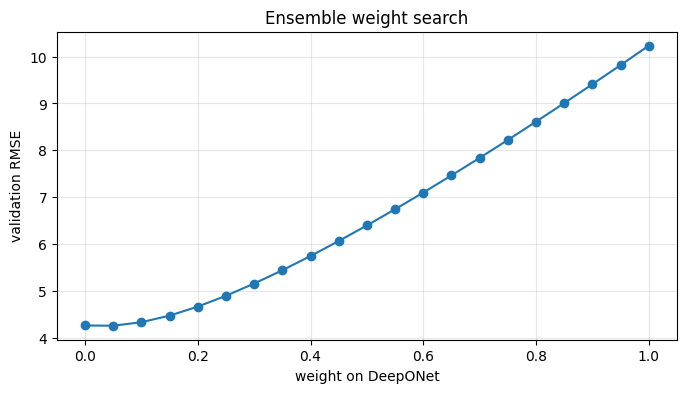

In [16]:
plt.figure(figsize=(8, 4))
plt.plot([x["weight_deeponet"] for x in val_search], [x["rmse_mean"] for x in val_search], marker="o")
plt.xlabel("weight on DeepONet")
plt.ylabel("validation RMSE")
plt.title("Ensemble weight search")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Final evaluation with selected weight

In [17]:
train_metrics = evaluate_dataset_with_weight(ds_train, best_w)
val_metrics = evaluate_dataset_with_weight(ds_val, best_w)
test_metrics = evaluate_dataset_with_weight(ds_test, best_w)

train_summary = summarize_metrics(train_metrics)
val_summary = summarize_metrics(val_metrics)
test_summary = summarize_metrics(test_metrics)

print("SELECTED WEIGHT")
print(json.dumps({"weight_deeponet": best_w, "weight_fno": 1.0 - best_w}, ensure_ascii=False, indent=2))

print("\nTRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))

print("\nVAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))

print("\nTEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

SELECTED WEIGHT
{
  "weight_deeponet": 0.05,
  "weight_fno": 0.95
}

TRAIN SUMMARY
{
  "mse_mean": 5.417226185106462,
  "mse_std": 1.0995880776148088,
  "rmse_mean": 2.3151008135464886,
  "rmse_std": 0.2398633131237567,
  "relative_l2_mean": 0.0015517200652562502,
  "relative_l2_std": 0.00016304082450124642,
  "psnr_mean": 38.52161141992713,
  "psnr_std": 0.9234086174391567
}

VAL SUMMARY
{
  "mse_mean": 31.92115815281868,
  "mse_std": 57.95369465434552,
  "rmse_mean": 4.258520042181015,
  "rmse_std": 3.7129725607307256,
  "relative_l2_mean": 0.002855199693585746,
  "relative_l2_std": 0.0024901239471469805,
  "psnr_mean": 35.36794219659697,
  "psnr_std": 5.50520631994984
}

TEST SUMMARY
{
  "mse_mean": 310.94102780342104,
  "mse_std": 162.56635563630772,
  "rmse_mean": 16.976728745698928,
  "rmse_std": 4.767778233273261,
  "relative_l2_mean": 0.011377433360321447,
  "relative_l2_std": 0.003192625946566019,
  "psnr_mean": 21.54352639039874,
  "psnr_std": 2.6241395128369356
}


## 8. Visualization

In [18]:
@torch.no_grad()
def show_prediction(dataset, idx, weight):
    x, c, meta = dataset[idx]
    pred_deepo, pred_fno = predict_pair(x)
    pred = weight * pred_deepo + (1.0 - weight) * pred_fno
    pred = np.clip(pred, -1.0, 1.0)
    target = c[0].numpy()

    pred_deepo_phys = denorm_c_from_minus1_1(pred_deepo, stats["c_min"], stats["c_max"])
    pred_fno_phys = denorm_c_from_minus1_1(pred_fno, stats["c_min"], stats["c_max"])
    pred_phys = denorm_c_from_minus1_1(pred, stats["c_min"], stats["c_max"])
    target_phys = denorm_c_from_minus1_1(target, stats["c_min"], stats["c_max"])

    fig, ax = plt.subplots(1, 5, figsize=(25, 4))

    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title(f"target | idx={idx}")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(pred_deepo_phys, origin="lower")
    ax[1].set_title("DeepONet v2")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(pred_fno_phys, origin="lower")
    ax[2].set_title("FNO v1")
    plt.colorbar(im2, ax=ax[2])

    im3 = ax[3].imshow(pred_phys, origin="lower")
    ax[3].set_title(f"ensemble (w={weight:.2f})")
    plt.colorbar(im3, ax=ax[3])

    im4 = ax[4].imshow(np.abs(pred_phys - target_phys), origin="lower")
    ax[4].set_title("|ensemble-target|")
    plt.colorbar(im4, ax=ax[4])

    plt.tight_layout()
    plt.show()
    print(meta["path"])

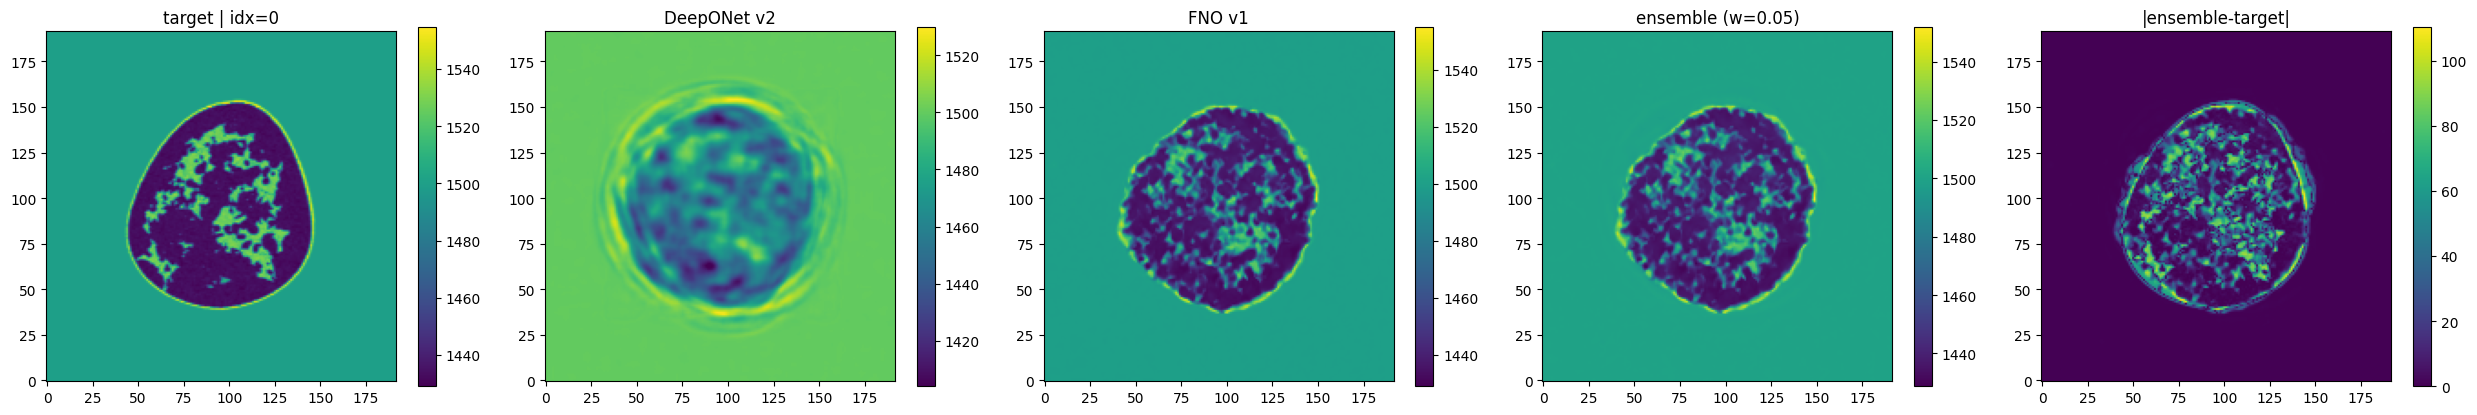

/workspace/usct_dataset_v2/test/sample_00000.npz


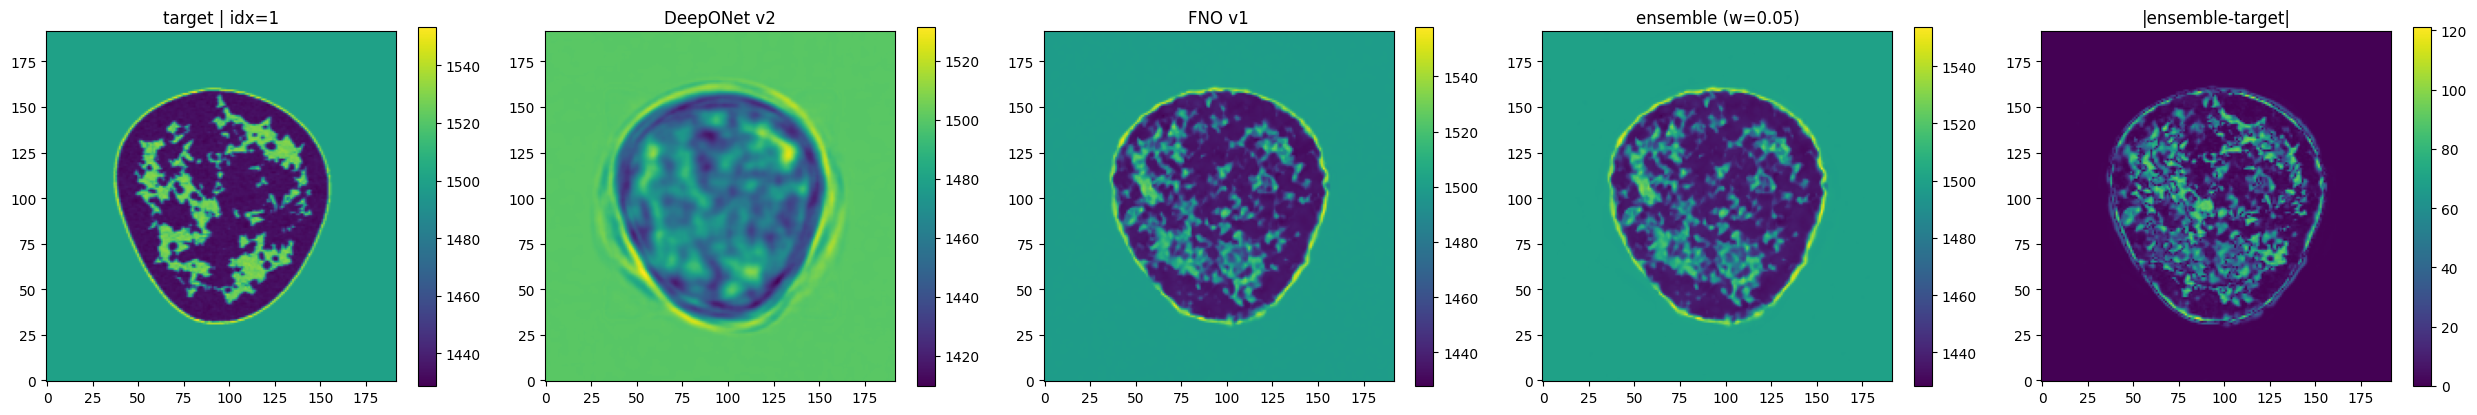

/workspace/usct_dataset_v2/test/sample_00001.npz


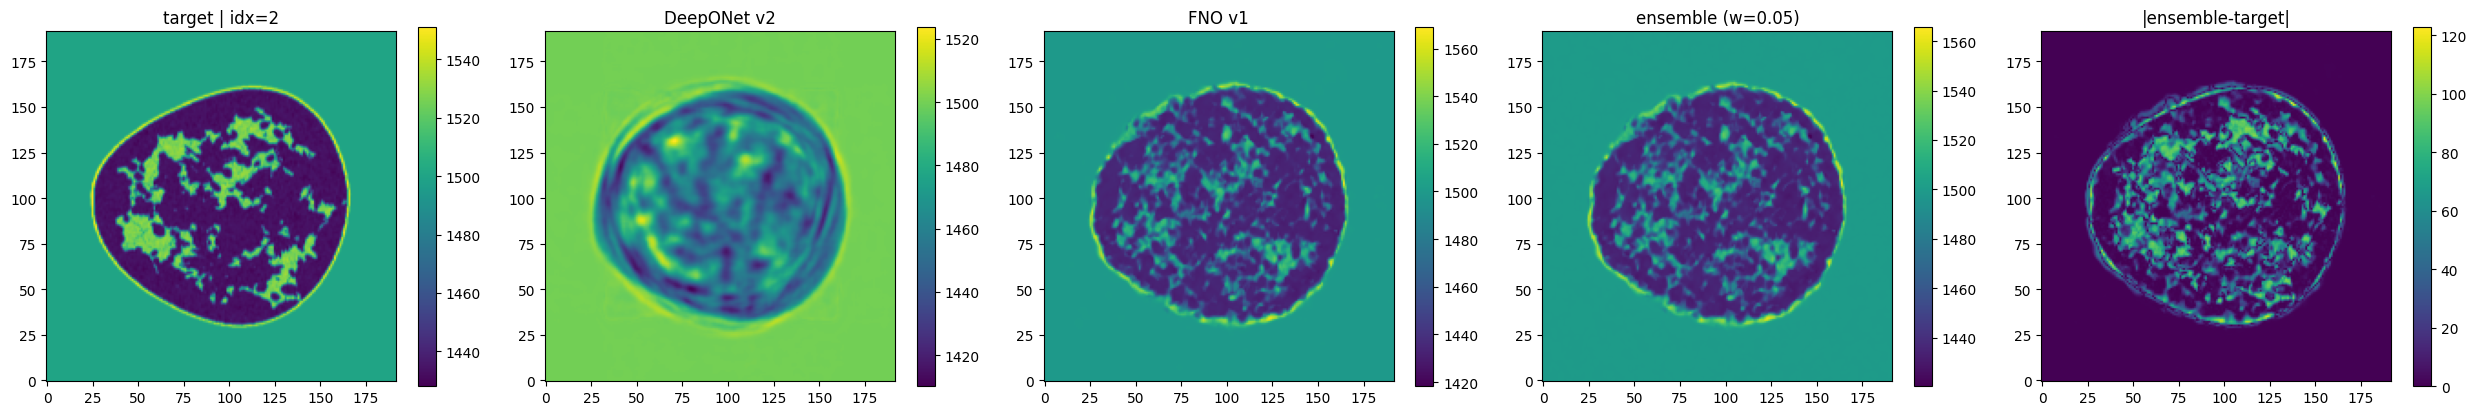

/workspace/usct_dataset_v2/test/sample_00002.npz


In [19]:
for idx in [0, 1, 2]:
    show_prediction(ds_test, idx, best_w)

## 9. Save artifacts

In [20]:
RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S),
            "R": int(R),
            "H": int(H),
            "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
            "selected_weight_deeponet": float(best_w),
            "selected_weight_fno": float(1.0 - best_w),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(RUN_DIR / "val_weight_search.json", "w", encoding="utf-8") as f:
    json.dump(val_search, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "train_summary.json", "w", encoding="utf-8") as f:
    json.dump(train_summary, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "val_summary.json", "w", encoding="utf-8") as f:
    json.dump(val_summary, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "train_metrics.json", "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "val_metrics.json", "w", encoding="utf-8") as f:
    json.dump(val_metrics, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

print("saved to:", RUN_DIR)

saved to: /workspace/reference_points/ensemble_deeponet_fno_v1
